In [ ]:
import os
import gemmi
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
from ecifp import utils, fp_sim
from rdkit import DataStructs
import numpy as np
from collections import defaultdict
import molviewspec as mvs
from sklearn.metrics import precision_score, recall_score, f1_score


In [ ]:
## Get the data directory
DATADIR = utils.get_data_dir()

In [27]:
def get_ligand_identifiers(pdb_dir):
    structure_seq_id = []
    structure_dir = pdb_dir
    for file in os.listdir(structure_dir):
        complex_id = file.split('.')[0]
        entry_id = complex_id[:4]
        chain_id = complex_id[-1]
        model = gemmi.read_structure(os.path.join(structure_dir, file))[0]
        ligands = model[chain_id].get_ligands()
        for ligand in ligands:
            structure_seq_id.append(
                {
                    "entry_id": entry_id,
                    "auth_asym_id": chain_id,
                    "auth_seq_id": ligand.seqid.num,
                }
            )
    structure_seq_id_df = pd.DataFrame.from_records(structure_seq_id)

    return structure_seq_id_df

In [28]:
def get_benchmark_data_with_ecifp(name: str, ecifp: pa.Table):
    lig_identifiers = pd.read_csv(DATADIR / f"{name}_ligand_identifiers.csv")
    mask = pc.is_in(ecifp['entry_id'], value_set=pa.array(lig_identifiers['entry_id'].to_list()))
    ecifp_flt = ecifp.filter(mask).select(
        ['entry_id', 'bm_id', 'complex_id', 'ligand_id', 'chem_comps']
        ).to_pandas()
    temp = ecifp_flt.explode('chem_comps').reset_index(drop=True)
    ecifp_flt_exploded = (temp
        .join(pd.json_normalize(temp['chem_comps']))
        .drop('chem_comps', axis=1))
    
    ecifp_flt_exploded = ecifp_flt_exploded[ecifp_flt_exploded['sym_op'].isna()]
    
    data = pd.merge(
        lig_identifiers,
        ecifp_flt_exploded[['entry_id', 'bm_id', 'complex_id', 'ligand_id', 'auth_asym_id', 'auth_seq_id']],
        on=['entry_id', 'auth_asym_id', 'auth_seq_id'],
        how='inner'
    )
    data["entry_chain"] = data["entry_id"] + data["auth_asym_id"]
    data.drop_duplicates(subset=['entry_chain'], inplace=True)

    return data

In [29]:
def get_targets(name: str):
    targets = pd.read_csv(DATADIR / f"{name}_structures.csv", names=["entry_chain_1", "entry_chain_2", "similar"])
    if name == "barelier":
        ligand_identifiers = pd.read_csv(DATADIR / f"{name}_ligand_identifiers.csv")
        targets = pd.merge(targets,
                           ligand_identifiers[["entry_id","auth_asym_id"]],
                            left_on='entry_chain_1',
                            right_on='entry_id',
                            how='left'
                            ).drop(columns=['entry_chain_1'])
        targets = pd.merge(targets,
                    ligand_identifiers[["entry_id","auth_asym_id"]],
                    left_on='entry_chain_2',
                    right_on='entry_id',
                    how='left',
                    suffixes=('_1', '_2'),
                    ).drop(columns=['entry_chain_2'])
        targets["entry_chain_1"] = targets["entry_id_1"] + targets["auth_asym_id_1"]
        targets["entry_chain_2"] = targets["entry_id_2"] + targets["auth_asym_id_2"]
        
    target_values = targets['similar'].apply(lambda x: 1 if x == 'active' else 0).values
    target_pairs = {key:target_values[i] for i, key in enumerate(zip(targets['entry_chain_1'], 
                        targets['entry_chain_2']))}
    return target_pairs

In [30]:
def get_ligand_ecfp_sim(benchmark_data: pd.DataFrame, target_pairs:dict[tuple[str, str], int]) -> pd.DataFrame:
    ligand_fps = {}
    for ligand_id in benchmark_data['ligand_id'].unique():
        component = utils.get_component(ligand_id)
        if component:
            fp = utils.generate_ecfp(component.mol, radius=2, fpSize=1024,atom_to_bits=False)
            ligand_fps[ligand_id] = fp
    
    entry_chains = benchmark_data['entry_chain'].values
    ligand_ids = benchmark_data['ligand_id'].values
    n = len(benchmark_data)

    ligand_ecfp_sim = defaultdict(list)

    for i in range(n - 1):
        query_lig_fp = ligand_fps[ligand_ids[i]]
        target_lig_fp = [ligand_fps[ligand_ids[j]] for j in range(i + 1, n)]
        sims = DataStructs.BulkTanimotoSimilarity(query_lig_fp, target_lig_fp)
        ligand_ecfp_sim["similarity"].extend(sims)

        query_chain = entry_chains[i]
        target_chains = entry_chains[i + 1:]

        expected_pairs = [
            target_pairs[(query_chain, chain)] if (query_chain, chain) in target_pairs
            else target_pairs[(chain, query_chain)] if (chain, query_chain) in target_pairs
            else np.nan
            for chain in target_chains
        ]
        ligand_ecfp_sim["active"].extend(expected_pairs)

        ligand_ecfp_sim["entry_chain_1"].extend([query_chain] * len(target_chains))
        ligand_ecfp_sim["entry_chain_2"].extend(list(target_chains))

        assert len(sims) == len(expected_pairs), f"Mismatch at index {i}: {len(sims)} != {len(expected_pairs)}"
    
    ligand_ecfp_sim = pd.DataFrame(ligand_ecfp_sim)
    ligand_ecfp_sim = ligand_ecfp_sim[~ligand_ecfp_sim['active'].isna()].reset_index(drop=True)
    return ligand_ecfp_sim

In [31]:
def get_ecifp_sim(benchmark_data: pd.DataFrame, ecifp: pa.Table, target_pairs:dict[tuple[str, str], int]) -> pd.DataFrame:
    mask = pc.is_in(ecifp['complex_id'], value_set=pa.array(benchmark_data['complex_id'].to_list()))
    filtered_ecifp = ecifp.filter(mask)

    ligand_ecifp, protein_ecifp = utils.get_ecifp(filtered_ecifp, "ligand_ecifp", "protein_ecifp")
    ecifp_sim = fp_sim.get_batch_ecifp_sim(ligand_ecifp, protein_ecifp, 0.5, 0.5)

    entry_chains = pd.merge(filtered_ecifp.select(["complex_id"]).to_pandas(),
                            benchmark_data[["complex_id", "entry_chain"]],
                            on="complex_id",
                            how="inner"
                            )["entry_chain"].values
    n = len(entry_chains)
    ecifp_sim_data = defaultdict(list)

    for i in range(n):
        for j in range(i+1, n):
            if (entry_chains[i], entry_chains[j]) in target_pairs:
                ecifp_sim_data["entry_chain_1"].append(entry_chains[i])
                ecifp_sim_data["entry_chain_2"].append(entry_chains[j])
                ecifp_sim_data["active"].append(target_pairs[(entry_chains[i], entry_chains[j])])
            elif (entry_chains[j], entry_chains[i]) in target_pairs :
                ecifp_sim_data["entry_chain_1"].append(entry_chains[j])
                ecifp_sim_data["entry_chain_2"].append(entry_chains[i])
                ecifp_sim_data["active"].append(target_pairs[(entry_chains[j], entry_chains[i])])
            else:
                ecifp_sim_data["entry_chain_1"].append(entry_chains[i])
                ecifp_sim_data["entry_chain_2"].append(entry_chains[j])
                ecifp_sim_data["active"].append(np.nan)

    ecifp_sim_data["similarity"] = ecifp_sim
    ecifp_sim_data = pd.DataFrame(ecifp_sim_data)
    ecifp_sim_data = ecifp_sim_data[~ecifp_sim_data['active'].isna()].reset_index(drop=True)
    
    return pd.DataFrame(ecifp_sim_data)

In [32]:
def get_classification_metrics(fp_sim_data: pd.DataFrame, cutoff: float = 0.3):
    y_true = fp_sim_data['active'].values
    y_pred = (fp_sim_data['similarity'] >= cutoff).astype(int)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return {"precision": precision, "recall": recall, "f1": f1}

In [33]:
protein_ligand_ecifp = pq.read_table(DATADIR / "protein_ligand_ecifp.parquet")

# Kahraman structures

## Binding site similarity based on ligand similarities

In [34]:
kahraman_with_ecifp = get_benchmark_data_with_ecifp("kahraman", protein_ligand_ecifp)
kahraman_target_pairs = get_targets("kahraman")
kahraman_ecfp_sim = get_ligand_ecfp_sim(kahraman_with_ecifp, kahraman_target_pairs)

In [35]:
kahraman_ecfp_sim["active"].value_counts()

active
0    1935
1     343
Name: count, dtype: int64

In [36]:
kahraman_with_ecifp.shape, kahraman_ecfp_sim.shape

((68, 7), (2278, 4))

In [37]:
(kahraman_baseline_auc, kahraman_baseline_auc_plot, kahraman_baseline_values) = utils.get_auc(kahraman_ecfp_sim['active'], kahraman_ecfp_sim['similarity'])
    

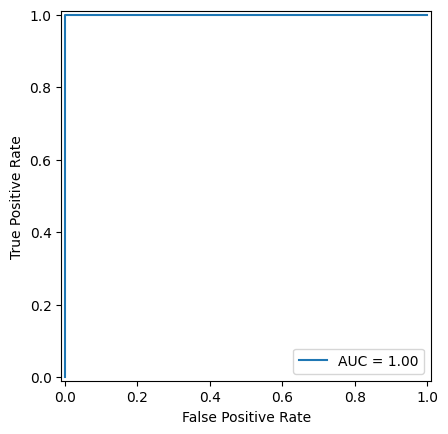

In [38]:
kahraman_baseline_auc_plot.plot()

In [39]:
get_classification_metrics(kahraman_ecfp_sim, cutoff=0.3)

{'precision': 0.31439046746104493, 'recall': 1.0, 'f1': 0.4783821478382148}

## Binding site similarity based on ECIFP similarities

In [40]:
kahraman_ecifp_sim = get_ecifp_sim(kahraman_with_ecifp, protein_ligand_ecifp, kahraman_target_pairs)

In [41]:
(kahraman_ecifp_auc, kahraman_ecifp_auc_plot, kahraman_ecifp_values) = utils.get_auc(kahraman_ecifp_sim['active'], kahraman_ecifp_sim['similarity'])

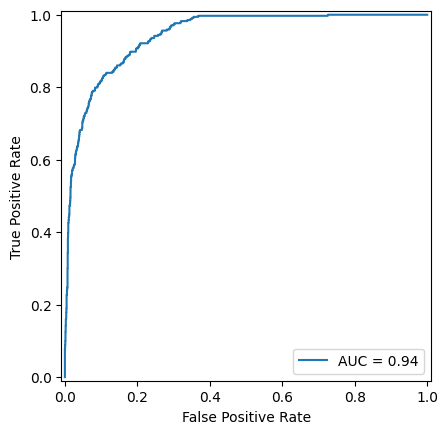

In [42]:
kahraman_ecifp_auc_plot.plot()

In [43]:
get_classification_metrics(kahraman_ecifp_sim, cutoff=0.3)

{'precision': 0.3506763787721124,
 'recall': 0.9825072886297376,
 'f1': 0.5168711656441718}

## Binding site pairs with class *inactive*, but having high ECIFP similarities

In [51]:
kahraman_high_ecifp_sim = kahraman_ecifp_sim[
    (kahraman_ecifp_sim['similarity'] > 0.5) &
    (kahraman_ecifp_sim['active'] == 0)
    ].merge(
    kahraman_with_ecifp[['entry_chain', 'auth_seq_id', 'ligand_id']],
    left_on="entry_chain_1",
    right_on="entry_chain",
    how="left"
).drop(columns=['entry_chain']).merge(
    kahraman_with_ecifp[['entry_chain', 'auth_seq_id', 'ligand_id']],
    left_on="entry_chain_2",
    right_on="entry_chain",
    how="left",
    suffixes=('_1', '_2')
).drop(columns=['entry_chain'])

In [53]:
kahraman_high_ecifp_sim

,entry_chain_1,entry_chain_2,active,similarity,auth_seq_id_1,ligand_id_1,auth_seq_id_2,ligand_id_2
0,12asA,1aylA,0,0.635502,332,AMP,544,ATP
1,12asA,1b8aA,0,0.653734,332,AMP,500,ATP
2,12asA,1e2qA,0,0.568124,332,AMP,302,ATP
3,12asA,1esqA,0,0.589665,332,AMP,300,ATP
4,12asA,1gn8A,0,0.577989,332,AMP,700,ATP
5,12asA,1hexA,0,0.512348,332,AMP,400,NAD
6,1a0iA,1amuA,0,0.577694,1,ATP,567,AMP
7,1a49A,1khtB,0,0.506370,535,ATP,2193,AMP
8,1amuA,1e8xA,0,0.523823,567,AMP,3000,ATP
9,1amuA,1kvkA,0,0.604417,567,AMP,535,ATP


# Identical structures

## Binding site similarity based on ligand similarities

In [9]:
identical_with_ecifp = get_benchmark_data_with_ecifp("identical", protein_ligand_ecifp)
identical_target_pairs = get_targets("identical")
identical_ecfp_sim = get_ligand_ecfp_sim(identical_with_ecifp, identical_target_pairs)

In [10]:
identical_ecfp_sim["active"].value_counts()

active
0    37124
1     5947
Name: count, dtype: int64

In [11]:
identical_with_ecifp.shape

(294, 7)

In [18]:
(identical_basealine_auc, identical_baseline_auc_plot, identical_baseline_values) = utils.get_auc(identical_ecfp_sim['active'], identical_ecfp_sim['similarity'])

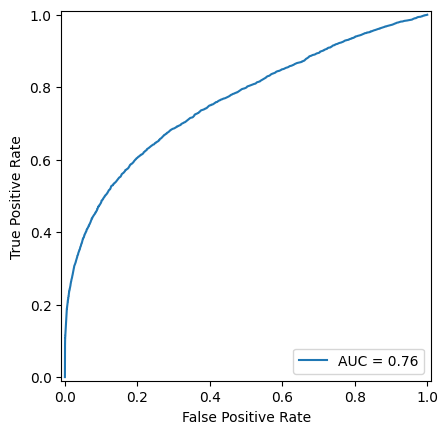

In [19]:
identical_baseline_auc_plot.plot()

In [12]:
get_classification_metrics(identical_ecfp_sim, cutoff=0.3)

{'precision': 0.757883484767504,
 'recall': 0.23843954935261477,
 'f1': 0.36275262215400356}

## Binding site similarity based on ECIFP similarities

In [15]:
identical_ecifp_sim = get_ecifp_sim(identical_with_ecifp, protein_ligand_ecifp, identical_target_pairs)

In [21]:
(identical_ecifp_auc, identical_ecifp_auc_plot, identical_ecifp_values) = utils.get_auc(identical_ecifp_sim['active'], identical_ecifp_sim['similarity'])

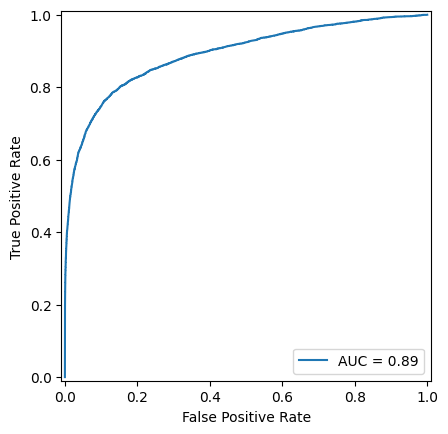

In [22]:
identical_ecifp_auc_plot.plot()

In [51]:
get_classification_metrics(identical_ecifp_sim, cutoff=0.3)

{'precision': 0.7315221733919297,
 'recall': 0.6157726584832689,
 'f1': 0.6686752487902857}

## Binding site pairs with class *active* but having low ligand similarities and high ECIFP similarities

In [13]:
identical_low_lig_sim = identical_ecfp_sim[(identical_ecfp_sim['similarity'] < 0.3) &
                                         (identical_ecfp_sim['active'] == 1)]

In [16]:
identical_high_ecifp_sim = identical_ecifp_sim[(identical_ecifp_sim['similarity'] > 0.5) &
                                               (identical_ecifp_sim['active'] == 1)
                                               ]

In [36]:
identical_low_high = pd.concat([pd.merge(
    identical_low_lig_sim,
    identical_high_ecifp_sim.drop(columns=['active']),
    on=['entry_chain_1', 'entry_chain_2'],
    how="inner",
    suffixes=('_lig', '_ecifp')),
    pd.merge(
        identical_low_lig_sim,
        identical_high_ecifp_sim.drop(columns=['active']),
        left_on=['entry_chain_1', 'entry_chain_2'],
        right_on=['entry_chain_2', 'entry_chain_1'],
        how="inner",
        suffixes=('_lig', '_ecifp')
    )
    .drop(
        columns=['entry_chain_1_ecifp', 'entry_chain_2_ecifp']
        ).rename(
            columns={'entry_chain_1_lig': 'entry_chain_1', 'entry_chain_2_lig': 'entry_chain_2'}
            )
], axis=0).merge(
    identical_with_ecifp[['entry_chain', 'auth_seq_id', 'ligand_id']],
    left_on="entry_chain_1",
    right_on="entry_chain",
    how="left"
).drop(columns=['entry_chain']).merge(
    identical_with_ecifp[['entry_chain', 'auth_seq_id', 'ligand_id']],
    left_on="entry_chain_2",
    right_on="entry_chain",
    how="left",
    suffixes=('_1', '_2')
).drop(columns=['entry_chain'])

In [43]:
identical_low_high.sort_values(by="entry_chain_1", ascending=True).head()

,similarity_lig,active,entry_chain_1,entry_chain_2,similarity_ecifp,auth_seq_id_1,ligand_id_1,auth_seq_id_2,ligand_id_2
4,0.265060,1,1bn1A,1bnvA,0.524700,555,AL5,555,AL7
18,0.259740,1,1bn1A,1bnnA,0.505291,555,AL5,555,AL1
9,0.243902,1,1bnwA,1bnvA,0.509943,555,TPD,555,AL7
24,0.253333,1,1bnwA,1bnnA,0.543557,555,TPD,555,AL1
19,0.289157,1,1i91A,1cimA,0.540619,555,INQ,264,PTS


# Barelier structures

## Binding site similarity based on ligand similarities

In [23]:
barelier_with_ecifp = get_benchmark_data_with_ecifp("barelier", protein_ligand_ecifp)
barelier_target_pairs = get_targets("barelier")
barelier_ecfp_sim = get_ligand_ecfp_sim(barelier_with_ecifp, barelier_target_pairs)

In [24]:
barelier_ecfp_sim["active"].value_counts()

active
0.0    32
1.0     9
Name: count, dtype: int64

In [25]:
barelier_with_ecifp.shape

(80, 7)

In [26]:
(barelier_baseline_auc, barelier_baseline_auc_plot, barelier_baseline_values) = utils.get_auc(barelier_ecfp_sim['active'], barelier_ecfp_sim['similarity'])

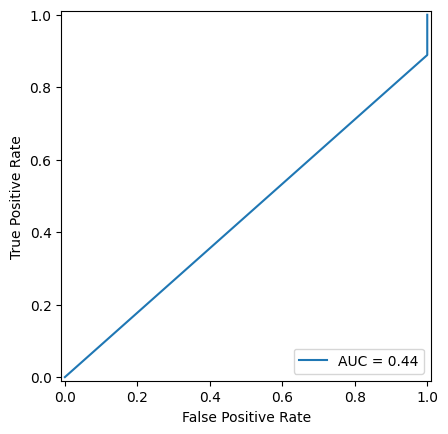

In [27]:
barelier_baseline_auc_plot.plot()

In [52]:
get_classification_metrics(barelier_ecfp_sim, cutoff=0.3)

{'precision': 0.2, 'recall': 0.8888888888888888, 'f1': 0.32653061224489793}

## Binding site similarity based on ECIFP similarities

In [28]:
barelier_ecifp_sim = get_ecifp_sim(barelier_with_ecifp, protein_ligand_ecifp, barelier_target_pairs)

In [29]:
(barelier_ecifp_auc, barelier_ecifp_auc_plot, barelier_ecifp_values) = utils.get_auc(barelier_ecifp_sim['active'], barelier_ecifp_sim['similarity'])

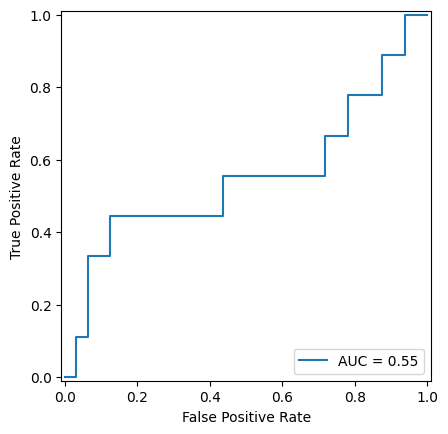

In [30]:
barelier_ecifp_auc_plot.plot()

In [53]:
get_classification_metrics(barelier_ecifp_sim, cutoff=0.3)

{'precision': 0.2222222222222222,
 'recall': 0.8888888888888888,
 'f1': 0.35555555555555557}

# Review structures

## Binding site similarity based on ligand similarities

In [57]:
review_with_ecifp = get_benchmark_data_with_ecifp("review", protein_ligand_ecifp)
review_target_pairs = get_targets("review")
review_ecfp_sim = get_ligand_ecfp_sim(review_with_ecifp, review_target_pairs)

In [36]:
review_ecfp_sim["active"].value_counts()

active
0.0    26199
1.0       17
Name: count, dtype: int64

In [37]:
(review_baseline_auc, review_baseline_auc_plot, review_baseline_values) = utils.get_auc(review_ecfp_sim['active'], review_ecfp_sim['similarity'])

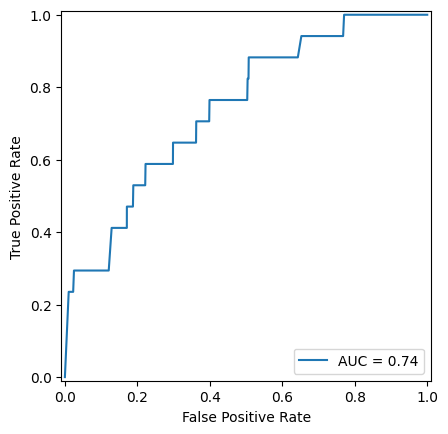

In [38]:
review_baseline_auc_plot.plot()

In [54]:
get_classification_metrics(review_ecfp_sim, cutoff=0.3)

{'precision': 0.0016245068461359943,
 'recall': 0.4117647058823529,
 'f1': 0.003236245954692557}

## Binding site similarity based on ECIFP similarities

In [58]:
review_ecifp_sim = get_ecifp_sim(review_with_ecifp, protein_ligand_ecifp, review_target_pairs)

In [57]:
(review_ecifp_auc, review_ecifp_auc_plot, review_ecifp_values) = utils.get_auc(review_ecifp_sim['active'], review_ecifp_sim['similarity'])

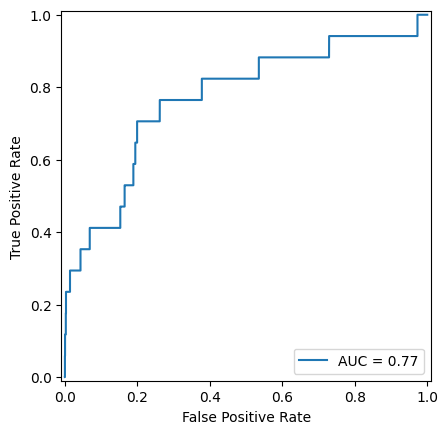

In [58]:
review_ecifp_auc_plot.plot()

In [55]:
get_classification_metrics(review_ecifp_sim, cutoff=0.3)

{'precision': 0.0018281535648994515,
 'recall': 0.4117647058823529,
 'f1': 0.003640145605824233}

## Binding site pairs with class *inactive*, but high ECIFP similarities

In [59]:
review_high_ecifp_sim = review_ecifp_sim[
    (review_ecifp_sim['similarity'] > 0.6) &
    (review_ecifp_sim['active'] == 0)
    ].merge(
    review_with_ecifp[['entry_chain', 'auth_seq_id', 'ligand_id']],
    left_on="entry_chain_1",
    right_on="entry_chain",
    how="left"
).drop(columns=['entry_chain']).merge(
    review_with_ecifp[['entry_chain', 'auth_seq_id', 'ligand_id']],
    left_on="entry_chain_2",
    right_on="entry_chain",
    how="left",
    suffixes=('_1', '_2')
).drop(columns=['entry_chain'])

In [ ]:
review_high_ecifp_sim

,entry_chain_1,entry_chain_2,active,similarity,auth_seq_id_1,ligand_id_1,auth_seq_id_2,ligand_id_2
0,1a49A,2w02B,0.0,0.614636,535,ATP,1588,ATP
1,1galA,1c0kA,0.0,0.610933,600,FAD,1363,FAD
2,1dg5A,1dapB,0.0,0.678631,200,NDP,400,NDP
3,1dg5A,1os1A,0.0,0.613386,200,NDP,541,ATP
4,1dg5A,3qwbD,0.0,0.662805,200,NDP,335,NDP
...,...,...,...,...,...,...,...,...
61,2hs6A,3p74A,0.0,0.693502,401,FMN,401,FMN
62,2mjpA,3qbwB,0.0,0.623553,500,ANP,602,ADP
63,2mjpA,3tw3A,0.0,0.620991,500,ANP,401,ATP
64,2mjpA,4bubA,0.0,0.637377,500,ANP,1486,ADP


In [63]:
review_high_ecifp_sim[review_high_ecifp_sim["entry_chain_1"]=="1e6wA"]

,entry_chain_1,entry_chain_2,active,similarity,auth_seq_id_1,ligand_id_1,auth_seq_id_2,ligand_id_2
6,1e6wA,1e3wD,0.0,0.918603,301,NAD,301,NAD
8,1e6wA,1jq5A,0.0,0.618477,301,NAD,401,NAD
9,1e6wA,1oaaA,0.0,0.665719,301,NAD,800,NAP
10,1e6wA,1orrB,0.0,0.649047,301,NAD,1300,NAD
11,1e6wA,1snyA,0.0,0.633750,301,NAD,400,NAP
12,1e6wA,1t2dA,0.0,0.610375,301,NAD,323,NAD
13,1e6wA,1u1iC,0.0,0.628388,301,NAD,1196,NAD
14,1e6wA,1xg5D,0.0,0.637581,301,NAD,1304,NAP
15,1e6wA,2b69A,0.0,0.664804,301,NAD,800,NAD
16,1e6wA,2ekpA,0.0,0.741309,301,NAD,1300,NAD


## Visualisation of superposed binding sites using MolViewSpec

In [ ]:
def get_transformation_matrix(entry_id_1, entry_id_2):
    # The transformation matrices are generated using US-align
    # after superposition of preferred assemblies of the PDB entries
    filename = DATADIR / f"review_benchmark_superposition/{entry_id_1}_{entry_id_2}_rotation_matrix.txt"
    transfrom_matrix = []
    if os.path.isfile(filename):
        with open(filename, 'r') as fh:
            for line in fh:
                if line.startswith(("0", "1", "2")):
                    temp = []
                    for value in line.strip().split(' ')[1:]:
                        if value != '':
                            temp.append(float(value))
                        
                    transfrom_matrix.append(temp)
    return np.array(transfrom_matrix)

In [ ]:
def viz_superposed_molview(identifier_1, identifier_2):
    entry_1_id, chain_1_id, seq_1_id = identifier_1.split('_')
    entry_2_id, chain_2_id, seq_2_id = identifier_2.split('_')
    base_url = "https://www.ebi.ac.uk/pdbe/entry-files/download/{}.bcif"
    assembly_1_id = utils.get_preferred_assembly(entry_1_id)
    assembly_2_id = utils.get_preferred_assembly(entry_2_id)
    transform_matrix = get_transformation_matrix(entry_1_id, entry_2_id)
    translation = transform_matrix[:, 0].tolist()
    rotation = transform_matrix[:, 1:].T.ravel().tolist()
    
    builder = mvs.create_builder()
    struct_1 = (
            builder
            .download(url=base_url.format(entry_1_id))
            .parse(format='bcif')
            .assembly_structure(assembly_id=assembly_1_id)
            .transform(rotation=rotation,translation=translation)
           )
    chain_1 = struct_1.component(selector=mvs.ComponentExpression(instance_id = 'ASM-1', auth_asym_id=chain_1_id))
    ligand_1 = struct_1.component(selector=mvs.ComponentExpression(instance_id = 'ASM-1',
                                                                   auth_asym_id=chain_1_id,
                                                                   auth_seq_id = int(seq_1_id),
                                                                   )
                                 )


    chain_1.representation(type='cartoon').color(color='grey')
    ligand_1.representation(type="ball_and_stick").color(color="cyan")
    
    struct_2 = (
            builder
            .download(url=base_url.format(entry_2_id))
            .parse(format='bcif')
            .assembly_structure(assembly_id=assembly_2_id)
           )
    chain_2 = struct_2.component(selector=mvs.ComponentExpression(instance_id = 'ASM-1', auth_asym_id=chain_2_id))
    ligand_2 = struct_2.component(selector=mvs.ComponentExpression(instance_id = 'ASM-1',
                                                                   auth_asym_id=chain_2_id,
                                                                   auth_seq_id = int(seq_2_id)))
    chain_2.representation(type='cartoon').color(color='grey')
    ligand_2.representation(type="ball_and_stick").color(color="orange")
    return builder

In [4]:
viz_superposed_molview('1e6w_A_301', '1e3w_D_301')

<IPython.core.display.Javascript object>

In [1]:
import pickle

In [4]:
with open("/Users/roshan/Downloads/D1.pkl", 'rb') as fh:
    data = pickle.load(fh)

In [7]:
data

{'1a42A': array([  3,  29, 104,  79,  91,  28, 100,  68,  12,  78,  22, 120, 108,
          5,  80,  58,  89,  17,  70,  34,  73,  26, 124, 101,  20, 117,
         93,  46, 126, 111,  52,  85,  38,  67,   4, 116,  69, 103,  35,
         87,  94,  37,  23,  51,  66,  15,  88, 127,  25,  83,  32,  99,
         50,  92,  62, 122,  95,  84,  75,  31,  39,   1,  19, 119,  97,
          8, 110, 107,  48, 128,  40,  16,  98,  56, 113,  71, 105,  82,
        102,  59,  61,   6, 121,  90,  76,  42,  60,  45, 109, 114, 118,
         10,  30,  13,   7,  11,  74,  24, 123,  18,  53,  63,  47, 125,
         72,   2,  44,  21,  86,  49,  77,  14,  65, 106,  43, 115,  81,
         54,  64,  27, 112,  57,  36,  96,  41,  55,   9,  33]),
 '1bk0A': array([ 25,   2,  58, 127,  60, 110,  27,  84, 100,  90, 119,   9,   6,
         16, 114,  67,  26, 103, 123,  87,  24,  21, 113, 117, 112,  66,
        105,  72,  81,  65, 126,  18,  50,  94,  78,  55, 115,  88, 108,
        101,  69,  46,  96,  99,  30, 106

In [6]:
len(data)

326